# Defoliation Statistics
Calculate minimum anomaly for each year and calculate the proportion of cells in outbreak, the probability of remaining in outbreak, and length of outbreak.

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

## Analysis Parameters

In [3]:
# Image dataset
imageset = '../images/images_TurkeyHill1/'

# Model fit dataset
modelset = '../data/TurkeyHill1.pkl'

# Data save location
save_csv = '../data/results_TurkeyHill1/mean_seasonal_anom_2021.csv'

# Image save location
save_image = '../data/results_TurkeyHill1/mean_seasonal_anom_2021.svg'

# Analysis year
year = 2021

## Load Data

In [4]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    #Sentinel-2
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    
    #Landsat
    #date = filename.name.split('_')[2] # get rid of .tif
    #date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)

images = xr.merge(da_list)
models = pd.read_pickle(modelset)

## Analysis

In [5]:
# Extract day of year and year information from system index
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    return safe_df

# Normalizes data within year
def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df

# Predict based on pwlf
def model_predict(intercepts, slopes, breaks, value):
    if value < breaks[0]:
        return slopes[0]*value + intercepts[0]
    for i in range(len(breaks)-1):
        if breaks[i] <= value and value < breaks[i+1]:
            return slopes[i]*(value) + intercepts[i]
    return slopes[-1]*value + intercepts[-1]

# Statistics/Defoliation Indices
def min_anom(df):
    return df['EVI_anom'].min()

def min_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].min()

def mean_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].mean()

def median_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].median()

def normalized_mean_seasonal(df):
    early_mask = (df['doy'] >= 150) & (df['doy'] <= 200)
    late_mask = (df['doy'] >= 200) & (df['doy'] <= 250)
    early_mean = df.loc[early_mask, 'EVI_anom'].mean()
    late_mean = df.loc[late_mask, 'EVI_anom'].mean()
    return (early_mean - late_mean) / (early_mean + late_mean)

def normalized_mean_seasonal_constrained(df):
    early_mask = (df['doy'] >= 150) & (df['doy'] <= 200)
    late_mask = (df['doy'] >= 200) & (df['doy'] <= 250)
    early_mean = np.min(df.loc[early_mask, 'EVI_anom'].mean(), 0)
    late_mean = np.min(df.loc[late_mask, 'EVI_anom'].mean(), 0)
    if (early_mean + late_mean) == 0:
        return np.nan
    else:
        return -1 * (early_mean - late_mean) / (early_mean + late_mean)

In [6]:
def process_point(dataset, latitude, longitude, year, stat_func = min_anom):
    # Paramters for analysis
    band = 'EVI'
    
    df = dataset.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    # Extract day of year and year information from system index
    df = add_doy_year(df)
    
    year_mask = df['Year'] >= 2019
    df = df.loc[year_mask]
    
    # Normalizes data within year
    df = normalize_VI(df, band)
    #df['EVI_nrml'] = df['EVI']
    
    mask = (models['lat'] == latitude) & (models['lon'] == longitude)
    intercepts = models.loc[mask, 'intercepts'].iloc[0]
    slopes = models.loc[mask, 'slopes'].iloc[0]
    breaks = models.loc[mask, 'breaks'].iloc[0]
    
    # Calculate anomaly
    df['EVI_pred'] = df['doy'].map((lambda x: model_predict(intercepts, slopes, breaks, x)))
    df['EVI_anom'] = df['EVI_nrml'] - df['EVI_pred']
    
    # Record minimum anomaly for specified year
    mask = (df['Year'] == year)
    
    return mean_summer_anom(df.loc[mask])

In [7]:
defol = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index:
            stat = process_point(images, y, x, year)
            defol.loc[len(defol.index)] = [y, x, stat]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

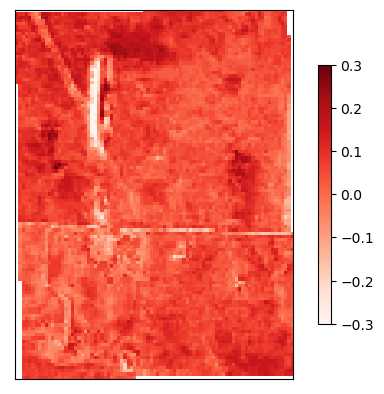

In [16]:
defol.to_csv(save_csv)
defol_pivot = (defol).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot * -1,  cmap='Reds', vmin=-0.3, vmax=0.3)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image, bbox_inches='tight')

In [9]:
defol

,lat,lon,stat
0,4701610.0,383220.000000,NaN
1,4701610.0,383230.119048,NaN
2,4701610.0,383240.238095,-0.072890
3,4701610.0,383250.357143,-0.105719
4,4701610.0,383260.476190,-0.087902
...,...,...,...
9600,4700480.0,384029.523810,-0.055212
9601,4700480.0,384039.642857,-0.039579
9602,4700480.0,384049.761905,-0.041909
9603,4700480.0,384059.880952,NaN


In [10]:
images

<xarray.Dataset>
Dimensions:  (lat: 113, lon: 85, time: 322)
Coordinates:
  * lat      (lat) float64 4.702e+06 4.702e+06 4.702e+06 ... 4.7e+06 4.7e+06
  * lon      (lon) float64 3.832e+05 3.832e+05 3.832e+05 ... 3.841e+05 3.841e+05
  * time     (time) datetime64[ns] 2018-12-25 2018-12-27 ... 2022-12-29
Data variables:
    EVI      (time, lat, lon) float64 nan nan nan nan ... 0.1284 0.1361 nan nan
    NIRv     (time, lat, lon) float64 nan nan nan nan ... 0.07165 nan nan

In [22]:
df = add_doy_year(images.isel(lat = 56, lon = 42).to_pandas().reset_index())
df = normalize_VI(df, 'EVI')

mask = (models['lat'] == 4701045.0) & (models['lon'] == 383645.0)
intercepts = models.loc[mask, 'intercepts'].iloc[0]
slopes = models.loc[mask, 'slopes'].iloc[0]
breaks = models.loc[mask, 'breaks'].iloc[0]
    
# Calculate anomaly
df['EVI_pred'] = df['doy'].map((lambda x: model_predict(intercepts, slopes, breaks, x)))
df['EVI_anom'] = df['EVI_nrml'] - df['EVI_pred']

In [23]:
df

,time,lat,lon,EVI,NIRv,Year,doy,EVI_nrml,EVI_pred,EVI_anom
0,2018-12-25,4701045.0,383645.0,NaN,NaN,2018,359,NaN,0.108901,NaN
1,2018-12-27,4701045.0,383645.0,NaN,NaN,2018,361,NaN,0.109969,NaN
2,2019-01-14,4701045.0,383645.0,NaN,NaN,2019,14,NaN,-0.104996,NaN
3,2019-01-21,4701045.0,383645.0,NaN,NaN,2019,21,NaN,-0.080719,NaN
4,2019-01-26,4701045.0,383645.0,NaN,NaN,2019,26,NaN,-0.063378,NaN
...,...,...,...,...,...,...,...,...,...,...
317,2022-12-01,4701045.0,383645.0,NaN,NaN,2022,335,NaN,0.096079,NaN
318,2022-12-04,4701045.0,383645.0,NaN,NaN,2022,338,NaN,0.097682,NaN
319,2022-12-21,4701045.0,383645.0,0.042166,0.036943,2022,355,0.040799,0.106764,-0.065965
320,2022-12-26,4701045.0,383645.0,NaN,NaN,2022,360,NaN,0.109435,NaN


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

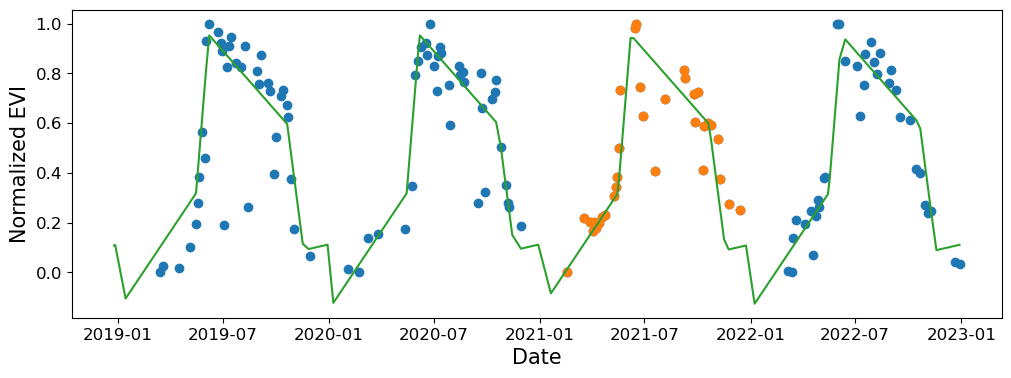

In [25]:
mask = (models['lat'] == df.loc[0, 'lat']) & (models['lon'] == df.loc[0, 'lon'])
intercepts = models.loc[mask, 'intercepts'].iloc[0]
slopes = models.loc[mask, 'slopes'].iloc[0]
breaks = models.loc[mask, 'breaks'].iloc[0]

plt.figure(figsize=(12,4))
x_grid = [x for x in range(63, 365)]
y_pred = [model_predict(intercepts, slopes, breaks, x) for x in x_grid]
mask = df['Year'] == 2021
plt.plot(df['time'], df['EVI_nrml'], 'o')
plt.plot(df.loc[mask, 'time'], df.loc[mask, 'EVI_nrml'], 'o')

plt.plot(df['time'], df['EVI_pred'])

plt.ylabel('Normalized EVI', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('../data/results_ArnotForest/abnormal_trend.svg')

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

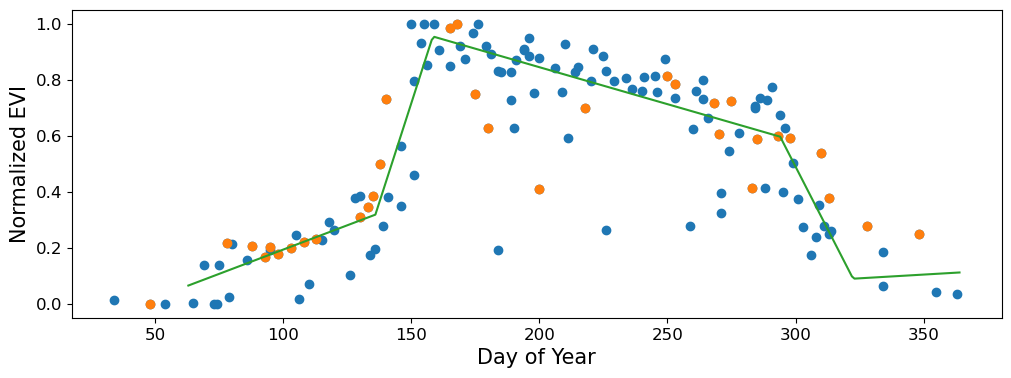

In [14]:
mask = (models['lat'] == df.loc[0, 'lat']) & (models['lon'] == df.loc[0, 'lon'])
intercepts = models.loc[mask, 'intercepts'].iloc[0]
slopes = models.loc[mask, 'slopes'].iloc[0]
breaks = models.loc[mask, 'breaks'].iloc[0]

plt.figure(figsize=(12,4))
x_grid = [x for x in range(63, 365)]
y_pred = [model_predict(intercepts, slopes, breaks, x) for x in x_grid]
mask = df['Year'] == 2021
plt.plot(df['doy'], df['EVI_nrml'], 'o')
plt.plot(df.loc[mask, 'doy'], df.loc[mask, 'EVI_nrml'], 'o')
plt.plot(x_grid, y_pred)
plt.ylabel('Normalized EVI', fontsize=15)
plt.xlabel('Day of Year', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('../data/results_ArnotForest/abnormal_trend.svg')

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7]),
 [Text(0, -0.1, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.20000000000000004, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5000000000000001, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7')])

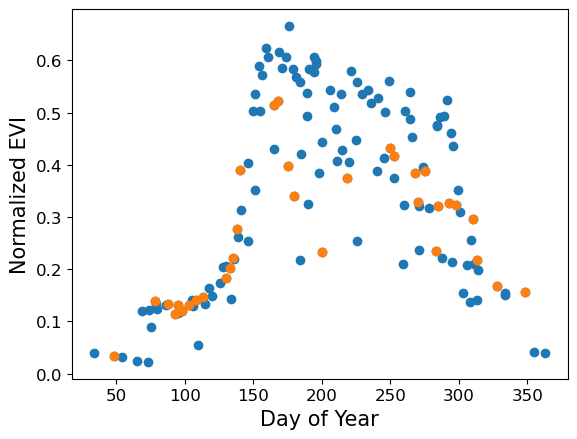

In [15]:
mask = df['Year'] == 2021
plt.plot(df['doy'], df['EVI'], 'o')
plt.plot(df.loc[mask, 'doy'], df.loc[mask, 'EVI'], 'o')
plt.ylabel('Normalized EVI', fontsize=15)
plt.xlabel('Day of Year', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)